In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv('/content/drive/MyDrive/loan_data (2).csv')

In [3]:
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [4]:
df['credit.policy'].value_counts()

,count
credit.policy,
1,7710
0,1868


In [5]:
df['purpose'].value_counts()

,count
purpose,
debt_consolidation,3957
all_other,2331
credit_card,1262
home_improvement,629
small_business,619
major_purchase,437
educational,343


In [6]:
df.shape

(9578, 14)

In [7]:
df.isnull().sum()

,0
credit.policy,0
purpose,0
int.rate,0
installment,0
log.annual.inc,0
dti,0
fico,0
days.with.cr.line,0
revol.bal,0
revol.util,0


In [8]:
from sklearn.preprocessing import OneHotEncoder

In [9]:
ohe=OneHotEncoder()
encoded=ohe.fit_transform(df[['purpose']])

In [10]:
encoded=pd.DataFrame(encoded.toarray(),columns=ohe.get_feature_names_out(['purpose']))

In [11]:
df=pd.concat([df.drop('purpose',axis=1),encoded],axis=1)

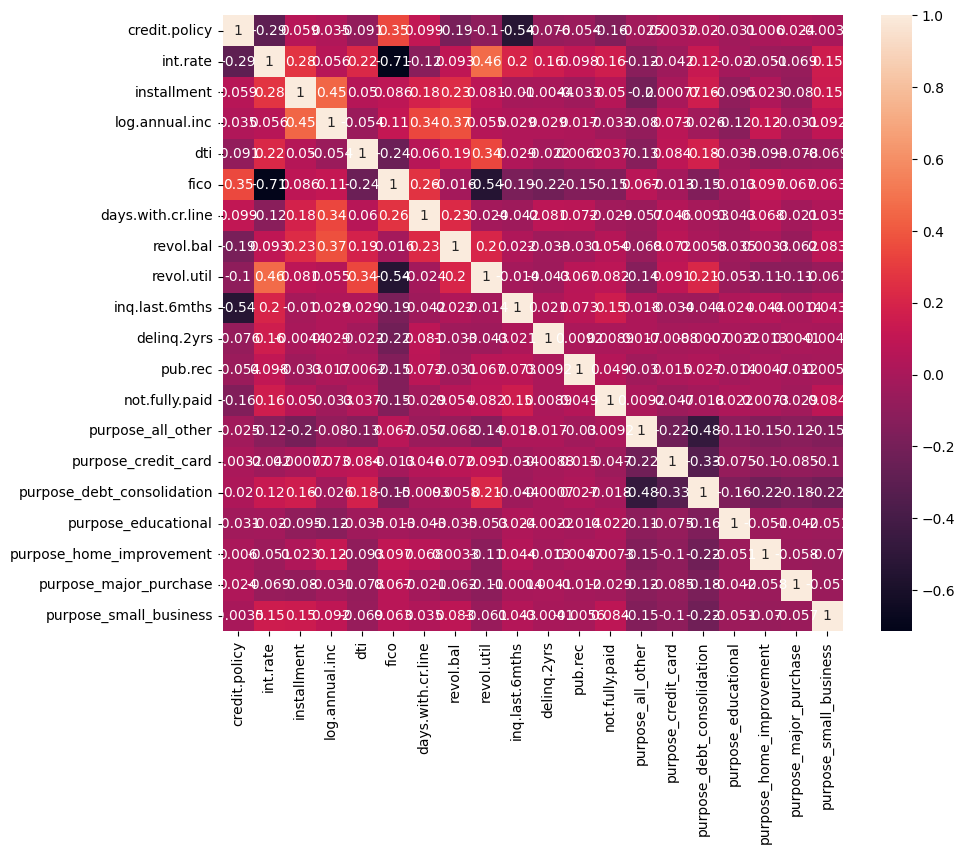

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [13]:
df.corr()['credit.policy'].sort_values(ascending=False)

,credit.policy
credit.policy,1.000000
fico,0.348319
days.with.cr.line,0.099026
installment,0.058770
log.annual.inc,0.034906
purpose_major_purchase,0.024281
purpose_debt_consolidation,0.020193
purpose_home_improvement,0.006036
purpose_credit_card,0.003216
purpose_small_business,-0.003511


In [14]:
corr_matrix=df.corr().abs()
high_corr_matrix=corr_matrix[corr_matrix>0.8]
print(high_corr_matrix)

                            credit.policy  int.rate  installment  \
credit.policy                         1.0       NaN          NaN   
int.rate                              NaN       1.0          NaN   
installment                           NaN       NaN          1.0   
log.annual.inc                        NaN       NaN          NaN   
dti                                   NaN       NaN          NaN   
fico                                  NaN       NaN          NaN   
days.with.cr.line                     NaN       NaN          NaN   
revol.bal                             NaN       NaN          NaN   
revol.util                            NaN       NaN          NaN   
inq.last.6mths                        NaN       NaN          NaN   
delinq.2yrs                           NaN       NaN          NaN   
pub.rec                               NaN       NaN          NaN   
not.fully.paid                        NaN       NaN          NaN   
purpose_all_other                     NaN       

In [15]:
corrle=corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
to_drop=[ column for column in corrle.columns  if any(corrle[column]>0.8)]
print ('columns to drop:', to_drop)

columns to drop: []


In [16]:
# There are no higly correlated columns in the dataset

In [17]:
x=df.drop('credit.policy',axis=1)
y=df['credit.policy']

In [18]:
print(x.shape)
print(y.shape)

(9578, 19)
(9578,)


In [19]:
df.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_all_other,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [21]:
print(x.shape)
print(y.shape)

(9578, 19)
(9578,)


In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1,stratify=y)

In [23]:
df.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_all_other,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,1,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [24]:
df['credit.policy'].value_counts().sum()

np.int64(9578)

In [25]:
df['int.rate'].value_counts().sum()

np.int64(9578)

In [26]:
ss=StandardScaler()

In [27]:
x_train_ss=ss.fit_transform(x_train)
x_test_ss=ss.transform(x_test)

In [28]:
# show columns that are non-numeric
non_num = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(non_num)

print(df.dtypes.value_counts())

[]
float64    13
int64       7
Name: count, dtype: int64


In [29]:
print((x_train=='credit_card').any().any())

False


In [30]:
cols=(x_train=='credit_card').any()
print(cols[cols].index.tolist())

[]


In [31]:
x_train.head()

,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_all_other,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
4177,0.1461,689.51,11.352232,15.15,697,5550.000000,32954,90.0,0,0,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7603,0.1273,537.06,11.211820,4.41,712,3841.041667,12585,38.8,1,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4166,0.1183,530.15,11.082143,4.91,742,3991.000000,9562,70.4,2,0,0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5374,0.0859,202.31,11.021798,7.90,747,2759.958333,5418,8.2,1,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1978,0.1537,522.70,11.813030,18.12,667,9000.041667,17258,81.4,1,1,0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [32]:
model=tf.keras.Sequential([
    tf.keras.layers.Dense(64,activation='relu',input_shape=(x_train.shape[1],)),
    tf.keras.layers.Dense(32,activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(16,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
from tensorflow.keras.callbacks import EarlyStopping
es=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [34]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [35]:
model.fit(x_train_ss,y_train,epochs=40,batch_size=32,validation_split=0.2,callbacks=es)

Epoch 1/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7749 - loss: 0.5002 - val_accuracy: 0.8917 - val_loss: 0.2628
Epoch 2/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8855 - loss: 0.2763 - val_accuracy: 0.9002 - val_loss: 0.2364
Epoch 3/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9039 - loss: 0.2406 - val_accuracy: 0.9080 - val_loss: 0.2271
Epoch 4/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9150 - loss: 0.2192 - val_accuracy: 0.9067 - val_loss: 0.2213
Epoch 5/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9145 - loss: 0.2152 - val_accuracy: 0.9159 - val_loss: 0.2093
Epoch 6/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9101 - loss: 0.2254 - val_accuracy: 0.9126 - val_loss: 0.2072
Epoch 7/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9149 - loss: 0.1945 - val_accuracy: 0.9204 - val_loss: 0.1969
Epoch 8/40
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9293 - loss: 0.1852 - val_accuracy: 0.

In [36]:
test_loss,test_accuracy=model.evaluate(x_test_ss,y_test)
print(test_loss)
print(test_accuracy)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9419 - loss: 0.1828
0.1589338779449463
0.9478079080581665


In [37]:
y_test_pred=model.predict(x_test_ss)
y_pred=(y_test_pred>0.5).astype(int)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [38]:
from sklearn.metrics import confusion_matrix,classification_report
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[ 322   52]
 [  48 1494]]
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       374
           1       0.97      0.97      0.97      1542

    accuracy                           0.95      1916
   macro avg       0.92      0.91      0.92      1916
weighted avg       0.95      0.95      0.95      1916



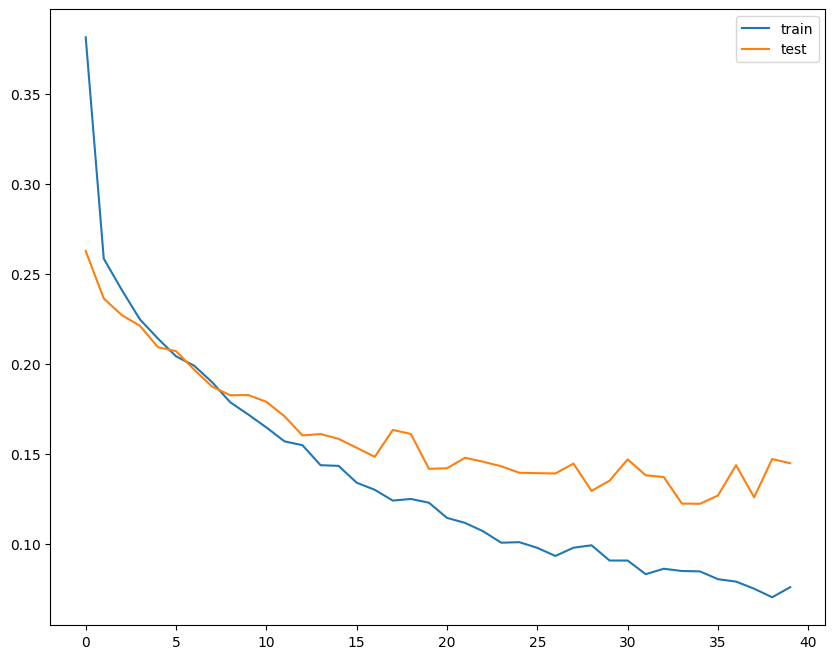

In [39]:
plt.figure(figsize=(10,8))
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.legend(['train','test'])
plt.show()

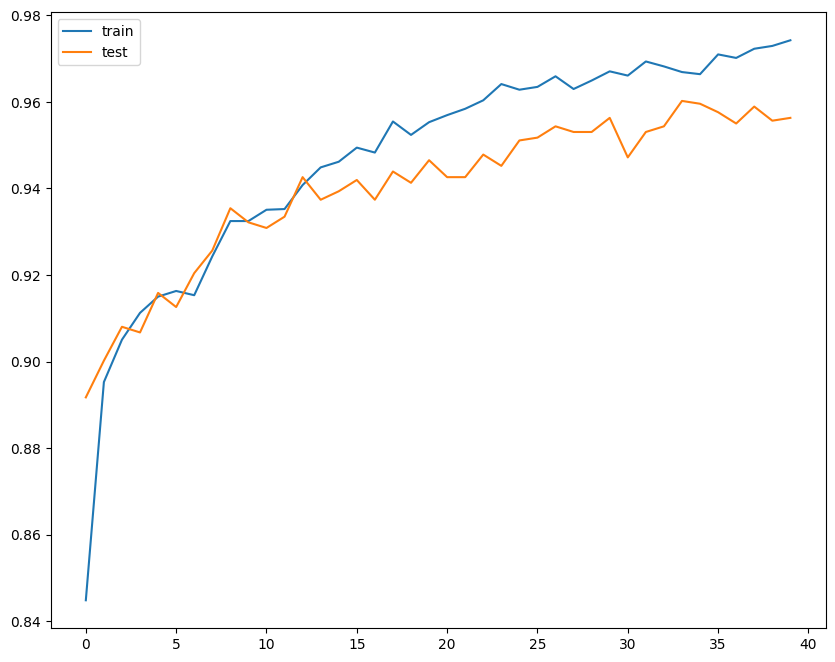

In [40]:
plt.figure(figsize=(10,8))
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.legend(['train','test'])
plt.show()